In [ ]:
from features import save_features, get_features
from productdata import get_productdata
from marketdata import get_marketdata
from scipy.io import loadmat

product_data = get_productdata()
market_data = get_marketdata()
divs = loadmat(r"C:\Users\UGGROO\OneDrive - Van Lanschot Kempen\Documents\MSc Thesis\3. Repos\spil-utilities\spil-core\MainFiles\StoredMarketdataFiles\historicDiv_2025-07-12.mat")

features = get_features(product_data, market_data, divs)

save_features(features)

In [1]:
import pandas as pd

# Load DataFrame from pickle file
df = pd.read_pickle("feature_files/features_saved_on_2025-07-12.pkl")
df = df.dropna()

# Ensure Date is in datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Sort DataFrame by Date
df = df.sort_values(by='Date')

# Define target (y) and features (X)
y = df['Price']
X = df.drop(columns=['Price', 'Date'])  # Exclude Date from features

# Compute the split index (80% train, 20% test)
split_index = int(len(df) * 0.8)

# Perform time-based train-test split
X_train_val, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train_val, y_test = y.iloc[:split_index], y.iloc[split_index:]

# Print shapes to verify
print(f"X_train shape: {X_train_val.shape}, X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train_val.shape}, y_test shape: {y_test.shape}")

X_train shape: (71871, 41), X_test shape: (17968, 41)
y_train shape: (71871,), y_test shape: (17968,)


In [2]:
import optuna
import numpy as np
import json
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


def tune_neural_net(trainval_X, trainval_y,
                    n_trials=50, random_state=42, n_splits=3):
    """
    Tune a funnel-structured neural network with Optuna using
    time-series cross-validation.
    """
    import tensorflow as tf
    tf.random.set_seed(random_state)
    np.random.seed(random_state)

    cv = TimeSeriesSplit(n_splits=n_splits)

    def build_model(trial, input_dim):
        model = Sequential()
        n_layers = trial.suggest_int("n_layers", 1, 5)
        activation = trial.suggest_categorical("activation", ["relu", "tanh", "selu", "swish"])
        dropout = trial.suggest_float("dropout", 0.0, 0.5)

        units = []
        units_l0 = trial.suggest_int("units_l0", 32, 512)
        units.append(units_l0)
        for i in range(1, n_layers):
            prev = units[i - 1]
            units_l = trial.suggest_int(f"units_l{i}", 8, prev)
            units.append(units_l)

        model.add(Input(shape=(input_dim,)))
        model.add(Dense(units[0], activation=activation))
        if dropout > 0:
            model.add(Dropout(dropout))

        for i in range(1, n_layers):
            model.add(Dense(units[i], activation=activation))
            if dropout > 0:
                model.add(Dropout(dropout))

        model.add(Dense(1))
        return model

    def objective(trial):
        learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
        batch_size = trial.suggest_categorical("batch_size", [64, 128, 256, 512])

        mses = []
        for train_idx, valid_idx in cv.split(trainval_X):
            if hasattr(trainval_X, "iloc"):
                X_train, X_valid = trainval_X.iloc[train_idx], trainval_X.iloc[valid_idx]
                y_train, y_valid = trainval_y.iloc[train_idx], trainval_y.iloc[valid_idx]
            else:
                X_train, X_valid = trainval_X[train_idx], trainval_X[valid_idx]
                y_train, y_valid = trainval_y[train_idx], trainval_y[valid_idx]

            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_valid_scaled = scaler.transform(X_valid)

            model = build_model(trial, X_train_scaled.shape[1])
            model.compile(optimizer=Adam(learning_rate=learning_rate), loss="mean_squared_error")
            early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

            model.fit(X_train_scaled, y_train,
                      validation_data=(X_valid_scaled, y_valid),
                      epochs=50,
                      batch_size=batch_size,
                      verbose=0,
                      callbacks=[early_stop])

            preds = model.predict(X_valid_scaled).flatten()
            mses.append(mean_squared_error(y_valid, preds))

        return float(np.mean(mses))

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials)
    best_params = study.best_params

    with open("models/best_hyperparameters_retuned.json", "w") as f:
        json.dump(best_params, f, indent=4)

    scaler = StandardScaler()
    full_X_scaled = scaler.fit_transform(trainval_X)

    best_model = Sequential()
    best_model.add(Input(shape=(full_X_scaled.shape[1],)))
    best_model.add(Dense(best_params["units_l0"], activation=best_params["activation"]))
    if best_params["dropout"] > 0:
        best_model.add(Dropout(best_params["dropout"]))

    for i in range(1, best_params["n_layers"]):
        best_model.add(Dense(best_params[f"units_l{i}"], activation=best_params["activation"]))
        if best_params["dropout"] > 0:
            best_model.add(Dropout(best_params["dropout"]))

    best_model.add(Dense(1))
    best_model.compile(optimizer=Adam(learning_rate=best_params["learning_rate"]),
                       loss="mean_squared_error")

    best_model.fit(full_X_scaled, trainval_y,
                   epochs=50,
                   batch_size=best_params["batch_size"],
                   verbose=0,
                   callbacks=[EarlyStopping(monitor="loss", patience=10,
                                            restore_best_weights=True)])

    return best_model, best_params, scaler



In [3]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from scipy.stats import skew, kurtosis, jarque_bera      
import numpy as np


def evaluate_nn_from_params(best_params, X_train_val, y_train_val,
                            X_test, y_test, random_state=42):
    """
    Evaluate a funnel-structured Keras neural network using best hyperparameters.
    """
    import tensorflow as tf
    tf.random.set_seed(random_state)
    np.random.seed(random_state)

 
    scaler = StandardScaler()
    X_train_val_scaled = scaler.fit_transform(X_train_val)
    X_test_scaled = scaler.transform(X_test)


    input_dim = X_train_val_scaled.shape[1]


    model = Sequential()
    model.add(Input(shape=(input_dim,)))

    n_layers = best_params["n_layers"]
    activation = best_params["activation"]
    dropout = best_params["dropout"]

    for i in range(n_layers):
        units = best_params[f"units_l{i}"]
        model.add(Dense(units, activation=activation))
        if dropout > 0:
            model.add(Dropout(dropout))

    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=best_params["learning_rate"]), loss='mse')


    early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

    model.fit(X_train_val_scaled, y_train_val,
              epochs=50,
              batch_size=best_params["batch_size"],
              verbose=0,
              callbacks=[early_stop])
    
    
    pred_in_sample = model.predict(X_train_val_scaled).flatten()

    in_sample_metrics = {
        "Average Absolute Error": mean_absolute_error(y_train_val, pred_in_sample),
        "Maximum Absolute Error": np.max(np.abs(y_train_val - pred_in_sample)),
        "MSE": mean_squared_error(y_train_val, pred_in_sample),
        "Root Mean Squared Error": root_mean_squared_error(y_train_val, pred_in_sample),
        "Adjusted MAPE (%)": np.mean(np.abs((y_train_val - pred_in_sample) / (max(y_train_val) - min(y_train_val)))) * 100,
        "Out of Sample R2": r2_score(y_train_val, pred_in_sample)}
    
   
    predictions = model.predict(X_test_scaled).flatten()

    avg_abs_error = mean_absolute_error(y_test, predictions)
    max_abs_error = np.max(np.abs(y_test - predictions))
    rmse = root_mean_squared_error(y_test, predictions)

    epsilon = 1e-8
    mape = np.mean(np.abs((y_test - predictions) / (y_test + epsilon))) * 100
    adjusted_mape = np.mean(np.abs((y_test - predictions) / (max(y_test) - min(y_test)))) * 100
    r2 = r2_score(y_test, predictions)

    errors = y_test - predictions
    mean_error = np.mean(errors)
    std_error = np.std(errors, ddof=1)
    skewness_error = skew(errors, bias=False)
    kurtosis_error = kurtosis(errors, fisher=False, bias=False)
    jb_stat, jb_p = jarque_bera(errors)

    out_sample_metrics = {
        "Average Absolute Error": avg_abs_error,
        "Maximum Absolute Error": max_abs_error,
        "Root Mean Squared Error": rmse,
        "Mean Absolute Percentage Error (%)": mape,
        "Adjusted MAPE (%)": adjusted_mape,
        "Out of Sample R2": r2,
        "Mean Error": mean_error,
        "Std Dev Error": std_error,
        "Skewness": skewness_error,
        "Kurtosis": kurtosis_error,
        "Jarque-Bera Statistic": jb_stat,
        "Jarque-Bera p-value": jb_p,
        "Pricing Errors": errors
    }

    return in_sample_metrics, out_sample_metrics

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import save_model
from sklearn.preprocessing import StandardScaler
import joblib
import numpy as np

def save_neural_net(best_params, X, y, model_path="models/trained_nn_model.keras", scaler_path="models/scaler.pkl", random_state=42):
    """
    Trains a funnel-structured Keras neural network on the full dataset and saves both model and scaler.

    Parameters:
        best_params (dict): Dictionary with 'n_layers', 'units_l{i}', 'activation', etc.
        X (array-like): Feature matrix.
        y (array-like): Target vector.
        model_path (str): Path to save the trained Keras model.
        scaler_path (str): Path to save the scaler used for input normalization.
        random_state (int): Random seed for reproducibility.

    Returns:
        None
    """
    import tensorflow as tf
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.callbacks import EarlyStopping
    from tensorflow.keras.layers import Dense, Dropout

    tf.random.set_seed(random_state)
    np.random.seed(random_state)

    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Build model
    input_dim = X_scaled.shape[1]
    model = Sequential()
    model.add(Input(shape=(input_dim,)))

    n_layers = best_params["n_layers"]
    activation = best_params["activation"]
    dropout = best_params["dropout"]

    for i in range(n_layers):
        units = best_params[f"units_l{i}"]
        model.add(Dense(units, activation=activation))
        if dropout > 0:
            model.add(Dropout(dropout))

    model.add(Dense(1))  # Output layer

    model.compile(optimizer=Adam(learning_rate=best_params["learning_rate"]),
                  loss='mean_squared_error')

    early_stop = EarlyStopping(monitor="loss", patience=10, restore_best_weights=True)
    model.fit(X_scaled, y,
              epochs=50,
              batch_size=best_params["batch_size"],
              verbose=0,
              callbacks=[early_stop])

    # Save model and scaler
    model.save(model_path)
    joblib.dump(scaler, scaler_path)

    print(f"Model saved to: {model_path}")
    print(f"Scaler saved to: {scaler_path}")

In [7]:
best_model, best_params, scaler = tune_neural_net(X_train_val, y_train_val, n_trials=200)
is_metrics, oos_metrics = evaluate_nn_from_params(best_params, X_train_val, y_train_val, X_test, y_test)

print("========== best params =============")
print(best_params)

print("========== in-sample =============")
print(is_metrics)

print("========== out-sample ============")
print(oos_metrics)


save_neural_net(best_params, X, y, model_path="models/nn_full_model_NOT_retuned.keras", scaler_path="models/scaler_NOT_retuned.pkl")


[I 2025-07-16 19:16:51,428] A new study created in memory with name: no-name-1e1059d2-1b22-4ecb-a79c-6632429fce4f


562/562 ━━━━━━━━━━━━━━━━━━━━ 0s 652us/step
562/562 ━━━━━━━━━━━━━━━━━━━━ 0s 595us/step
562/562 ━━━━━━━━━━━━━━━━━━━━ 0s 650us/step


[I 2025-07-16 19:17:59,504] Trial 0 finished with value: 2.8908931889137435 and parameters: {'learning_rate': 0.00034021562693951646, 'batch_size': 128, 'n_layers': 1, 'activation': 'selu', 'dropout': 0.1637922011568388, 'units_l0': 41}. Best is trial 0 with value: 2.8908931889137435.


562/562 ━━━━━━━━━━━━━━━━━━━━ 0s 715us/step
562/562 ━━━━━━━━━━━━━━━━━━━━ 0s 709us/step
562/562 ━━━━━━━━━━━━━━━━━━━━ 0s 683us/step


[I 2025-07-16 19:18:20,797] Trial 1 finished with value: 1.4561764433737683 and parameters: {'learning_rate': 0.008151089176752545, 'batch_size': 512, 'n_layers': 3, 'activation': 'relu', 'dropout': 0.08184388712415408, 'units_l0': 164, 'units_l1': 30, 'units_l2': 22}. Best is trial 1 with value: 1.4561764433737683.


...

562/562 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
562/562 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
562/562 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


[I 2025-07-17 03:05:19,768] Trial 198 finished with value: 1.0292570980216904 and parameters: {'learning_rate': 0.0003366394575898959, 'batch_size': 256, 'n_layers': 4, 'activation': 'swish', 'dropout': 0.0509896230919684, 'units_l0': 245, 'units_l1': 241, 'units_l2': 236, 'units_l3': 230}. Best is trial 113 with value: 0.7388104460729155.


562/562 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
562/562 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
562/562 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


[I 2025-07-17 03:08:12,161] Trial 199 finished with value: 1.2746265789284041 and parameters: {'learning_rate': 0.0016159151829679024, 'batch_size': 512, 'n_layers': 4, 'activation': 'swish', 'dropout': 0.489018811681953, 'units_l0': 318, 'units_l1': 258, 'units_l2': 253, 'units_l3': 246}. Best is trial 113 with value: 0.7388104460729155.


2246/2246 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
562/562 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
========== best params =============
{'learning_rate': 0.0009460885408341267, 'batch_size': 256, 'n_layers': 4, 'activation': 'swish', 'dropout': 0.09026861001620974, 'units_l0': 249, 'units_l1': 242, 'units_l2': 232, 'units_l3': 225}
========== in-sample =============
{'Average Absolute Error': 0.1491341037747754, 'Maximum Absolute Error': 8.408606876846314, 'MSE': 0.09722329061969923, 'Root Mean Squared Error': 0.31180649547387435, 'Adjusted MAPE (%)': 0.43579410726842777, 'Out of Sample R2': 0.9966689117890477}
========== out-sample ============
{'Average Absolute Error': 0.381368056315159, 'Maximum Absolute Error': 6.620091915130615, 'Root Mean Squared Error': 0.629664596093437, 'Mean Absolute Percentage Error (%)': 373722482.0095493, 'Adjusted MAPE (%)': 1.5077085240469963, 'Out of Sample R2': 0.985938994994646, 'Mean Error': 0.24085282164047814, 'Std Dev Error': 0.5817957203038213, 'Skewness': -0.

In [5]:
best_params = {'learning_rate': 0.0009460885408341267, 'batch_size': 256, 'n_layers': 4, 'activation': 'swish', 'dropout': 0.09026861001620974, 'units_l0': 249, 'units_l1': 242, 'units_l2': 232, 'units_l3': 225}
is_metrics, oos_metrics = evaluate_nn_from_params(best_params, X_train_val, y_train_val, X_test, y_test)

print("========== in-sample =============")
print(is_metrics)

print("========== out-sample ============")
print(oos_metrics)

oos_metrics['Pricing Errors'].to_csv("errors/nn_errors_not_retuned.csv", index = False)

2246/2246 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
562/562 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
========== in-sample =============
{'Average Absolute Error': 0.12569117920860218, 'Maximum Absolute Error': 8.474219192977905, 'MSE': 0.08618490741062507, 'Root Mean Squared Error': 0.2935726612111984, 'Adjusted MAPE (%)': 0.3672900687923904, 'Out of Sample R2': 0.997047111579873}
========== out-sample ============
{'Average Absolute Error': 0.3132711705980427, 'Maximum Absolute Error': 6.304736719955445, 'Root Mean Squared Error': 0.5391276473062357, 'Mean Absolute Percentage Error (%)': 367131164.61744803, 'Adjusted MAPE (%)': 1.2384928586114394, 'Out of Sample R2': 0.9896918431056041, 'Mean Error': 0.16818311662934837, 'Std Dev Error': 0.5122378963178501, 'Skewness': 0.6103275882056037, 'Kurtosis': 37.815735241788495, 'Jarque-Bera Statistic': 908078.3623562951, 'Jarque-Bera p-value': 0.0, 'Pricing Errors': 84675   -0.072464
73825    0.010286
69395   -0.184330
63475    0.287962
69394   -0.149386
    

<class 'sklearn.preprocessing._data.StandardScaler'> True


PermutationExplainer explainer: 301it [19:56,  4.03s/it]                         


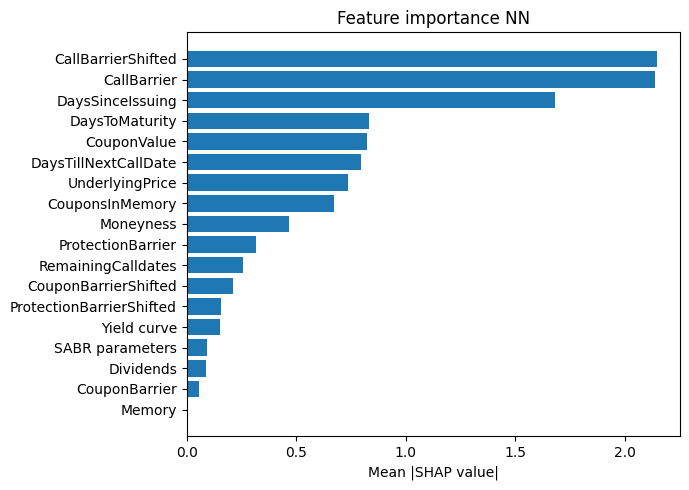

In [12]:
import joblib
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from tensorflow import keras

# --- paths ---
NN_MODEL_PATH = "models/nn_full_model_retuned_3.keras"
X_SCALER_PATH = "models/scaler_retuned_3.pkl"            # saved by your function

# --- load model + scaler ---
nn_model    = keras.models.load_model(NN_MODEL_PATH)
nn_x_scaler = joblib.load(X_SCALER_PATH)       # must have .transform

# quick sanity:
print(type(nn_x_scaler), hasattr(nn_x_scaler, "transform"))  # expect True

# --- X_train_val and X_test must be DataFrames with same columns as training ---
# X_train_val = pd.read_pickle("X_train_val.pkl")
# X_test      = pd.read_pickle("X_test.pkl")

def predict_nn(X):
    X_in = nn_x_scaler.transform(X)   # apply the saved scaler
    y = nn_model.predict(X_in, verbose=0)
    return np.asarray(y).ravel()

# background for SHAP
# bg = X_train_val.sample(min(200, len(X_train_val)), random_state=0)
# explainer   = shap.Explainer(predict_nn, shap.maskers.Independent(bg))
# shap_values = explainer(X_test.sample(200, random_state=42))

sim_df = pd.read_pickle(
    r"C:\Users\14gij\OneDrive\Documenten\1 Master\Thesis\thesis code\ML Training\feature_files\sim_features_large3_2025-07-21"
)
sim_df = sim_df.dropna()

# Define target (y) and features (X)
y_sim_test = sim_df['Price']
X_sim_test = sim_df.drop(columns=['Price', 'Date'])


bg = X.sample(min(500, len(X)), random_state=42)
explainer   = shap.Explainer(predict_nn, bg) #shap.maskers.Independent(bg)
shap_values = explainer(X_sim_test.iloc[:300]) # .sample(300, random_state=42)



# --- grouped importance (your grouping) ---
yield_cols = ['1BD','1WK','1MO','2MO','6MO','12MO','2YR','3YR','4YR','5YR','7YR']
sabr_cols  = ['AlphaA','AlphaB','AlphaC','RhoA','RhoB','RhoC','NuB','NuC']
div_cols   = ['q1','q2','q3','q4','q5','q6','q7']

group_dict = {
    'Yield curve'     : yield_cols,
    'SABR parameters' : sabr_cols,
    'Dividends'       : div_cols,
}

def grouped_mean_abs_shap(shap_expl, X_ref, groups, add_singletons=True):
    cols = list(X_ref.columns)
    vals = np.asarray(shap_expl.values)  # (n_samples, n_features)
    out  = {}
    grouped = set()
    for gname, gcols in groups.items():
        present = [c for c in gcols if c in cols]
        if not present:
            continue
        idx = [cols.index(c) for c in present]
        out[gname] = np.mean(np.abs(vals[:, idx]))
        grouped.update(present)
    if add_singletons:
        for c in cols:
            if c not in grouped:
                out[c] = np.mean(np.abs(vals[:, cols.index(c)]))
    return dict(sorted(out.items(), key=lambda kv: kv[1], reverse=True))

group_importance = grouped_mean_abs_shap(shap_values, X_sim_test, group_dict, add_singletons=True)

# --- plot ---
plt.figure(figsize=(7,5))
labels = list(group_importance.keys())
values = list(group_importance.values())
plt.barh(labels, values)
plt.gca().invert_yaxis()
plt.xlabel('Mean |SHAP value|')
plt.title('Feature importance NN')
plt.tight_layout()
plt.show()

# Optional: individual top-20 bar
# shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=20, show=True)


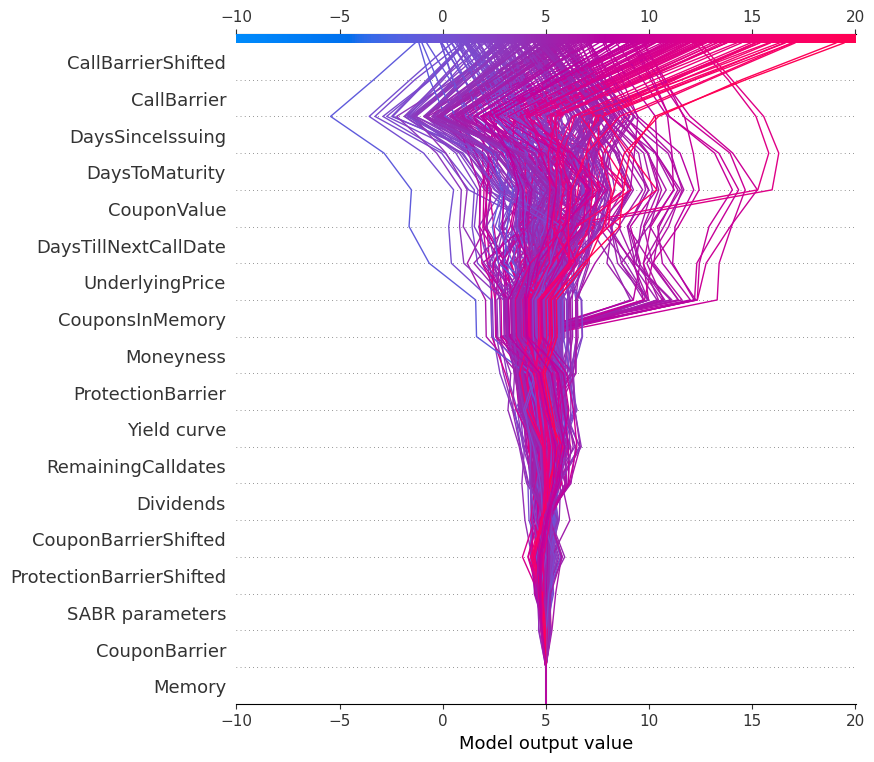

In [13]:
# --- SHAP decision plot with grouped features for a subsample of the first 200 observations ---
import numpy as np
import itertools

# 1) Build groups using your existing group_dict and add singletons
all_cols = list(X_sim_test.columns)
grouped_features = set(itertools.chain.from_iterable(group_dict.values()))

group_to_idx = {
    gname: [all_cols.index(c) for c in gcols if c in all_cols]
    for gname, gcols in group_dict.items()
}
for c in all_cols:
    if c not in grouped_features:
        group_to_idx[c] = [all_cols.index(c)]

group_names = list(group_to_idx.keys())

# 2) Aggregate SHAP values per group for ALL samples -> [n_samples x n_groups]
sv = shap_values.values  # shape: [n_samples x n_features]
group_sv_mat = np.column_stack([
    sv[:, idxs].sum(axis=1) if len(idxs) > 1 else sv[:, idxs[0]]
    for idxs in group_to_idx.values()
])

# 3) Order groups by global importance (mean |SHAP|) for cleaner plotting
order = np.argsort(np.mean(np.abs(group_sv_mat), axis=0))
group_sv_mat = group_sv_mat[:, order]
group_names_ordered = [group_names[j] for j in order]

# 4) Subsample the first 200 observations (avoid very large, slow plot)
idx = np.arange(min(500, group_sv_mat.shape[0]))

# 5) Use a scalar base value (average of base values across samples)
base_value_scalar = float(np.mean(shap_values.base_values))

# 6) Decision plot showing grouped paths for the subsample
shap.decision_plot(
    base_value=base_value_scalar,
    shap_values=group_sv_mat,  #[idx, :]
    feature_names=group_names_ordered,
    link="identity",
    show=True
)


PermutationExplainer explainer: 17969it [2:14:44,  2.22it/s]                             
C:\Users\UGGROO\AppData\Local\Temp\ipykernel_2924\4269059711.py:16: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="bar", show=True)


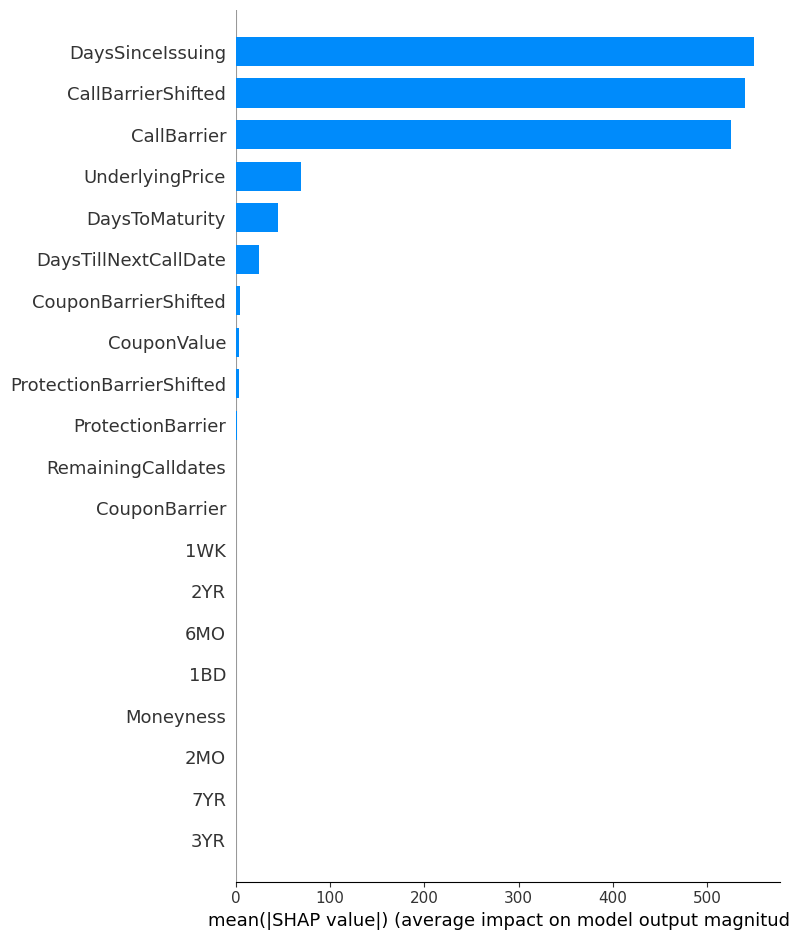

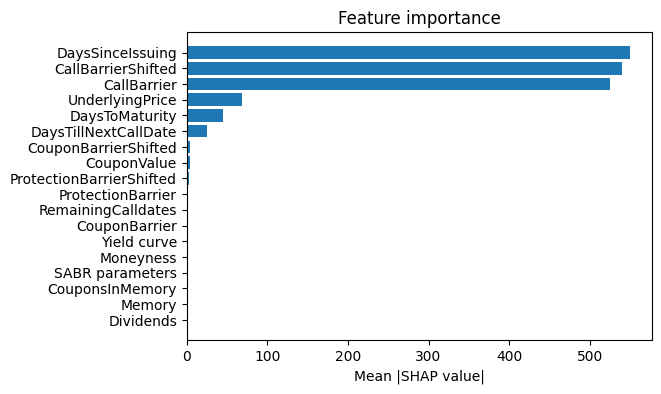

In [5]:
import shap
import tensorflow as tf
import numpy as np
import pandas as pd


nn_model = tf.keras.models.load_model("models/nn_full_model_NOT_retuned.keras")

background = shap.sample(X_train_val, 200, random_state=0)   


explainer = shap.Explainer(nn_model, background)

shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test, plot_type="bar", show=True)





import itertools
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# 1. Which columns belong to which logical group?
yield_cols = ['1BD', '1WK', '1MO', '2MO', '6MO', '12MO',
              '2YR', '3YR', '4YR', '5YR', '7YR']
sabr_cols  = ['AlphaA', 'AlphaB', 'AlphaC',
              'RhoA', 'RhoB', 'RhoC',
              'NuB',  'NuC']
div_cols   = ['q1', 'q2', 'q3', 'q4', 'q5', 'q6', 'q7']

group_dict = {
    'Yield curve' : yield_cols,
    'SABR parameters'  : sabr_cols,
    'Dividends'   : div_cols,
}

all_cols = list(X_test.columns)

# ----------------------------------------------------------------------
# 2. Aggregate SHAP values for the *defined* groups
group_importance = {}
for gname, gcols in group_dict.items():
    idx = [all_cols.index(c) for c in gcols]
    group_importance[gname] = np.abs(shap_values.values[:, idx]).mean()

# ----------------------------------------------------------------------
# 3. OPTIONAL: keep only features that are NOT in any group
#     (Skip this entire block if you do not want singletons at all.)
grouped_features = set(itertools.chain.from_iterable(group_dict.values()))

for c in all_cols:
    if c not in grouped_features:
        group_importance[c] = np.abs(
            shap_values.values[:, all_cols.index(c)]
        ).mean()

# ----------------------------------------------------------------------
# 4. Plot the result
group_importance = dict(
    sorted(group_importance.items(), key=lambda kv: kv[1], reverse=True)
)

plt.figure(figsize=(6, 4))
plt.barh(list(group_importance.keys()), list(group_importance.values()))
plt.gca().invert_yaxis()
plt.xlabel('Mean |SHAP value|')
plt.title('Feature importance')
plt.show()

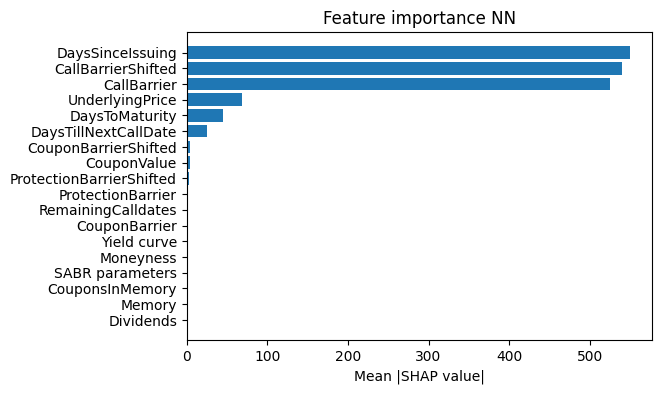

In [6]:
import itertools
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# 1. Which columns belong to which logical group?
yield_cols = ['1BD', '1WK', '1MO', '2MO', '6MO', '12MO',
              '2YR', '3YR', '4YR', '5YR', '7YR']
sabr_cols  = ['AlphaA', 'AlphaB', 'AlphaC',
              'RhoA', 'RhoB', 'RhoC',
              'NuB',  'NuC']
div_cols   = ['q1', 'q2', 'q3', 'q4', 'q5', 'q6', 'q7']

group_dict = {
    'Yield curve' : yield_cols,
    'SABR parameters'  : sabr_cols,
    'Dividends'   : div_cols,
}

all_cols = list(X_test.columns)

# ----------------------------------------------------------------------
# 2. Aggregate SHAP values for the *defined* groups
group_importance = {}
for gname, gcols in group_dict.items():
    idx = [all_cols.index(c) for c in gcols]
    group_importance[gname] = np.abs(shap_values.values[:, idx]).mean()

# ----------------------------------------------------------------------
# 3. OPTIONAL: keep only features that are NOT in any group
#     (Skip this entire block if you do not want singletons at all.)
grouped_features = set(itertools.chain.from_iterable(group_dict.values()))

for c in all_cols:
    if c not in grouped_features:
        group_importance[c] = np.abs(
            shap_values.values[:, all_cols.index(c)]
        ).mean()

# ----------------------------------------------------------------------
# 4. Plot the result
group_importance = dict(
    sorted(group_importance.items(), key=lambda kv: kv[1], reverse=True)
)

plt.figure(figsize=(6, 4))
plt.barh(list(group_importance.keys()), list(group_importance.values()))
plt.gca().invert_yaxis()
plt.xlabel('Mean |SHAP value|')
plt.title('Feature importance NN')
plt.show()

In [37]:
best_params = {'learning_rate': 0.0009460885408341267, 'batch_size': 256, 'n_layers': 4, 'activation': 'swish', 'dropout': 0.09026861001620974, 'units_l0': 249, 'units_l1': 242, 'units_l2': 232, 'units_l3': 225}

df_test = X_test.copy()             
df_test["target"] = y_test

mask_lt50 = df_test['DaysTillNextCallDate'] < 50
mask_ge50 = ~mask_lt50              

test_lt50 = df_test[mask_lt50].reset_index(drop=True)
test_ge50 = df_test[mask_ge50].reset_index(drop=True)

X_test_lt50, y_test_lt50 = test_lt50.drop(columns="target"), test_lt50["target"]
X_test_ge50, y_test_ge50 = test_ge50.drop(columns="target"), test_ge50["target"]

print(f"< 50 days : {len(X_test_lt50)} samples")
print(f"≥ 50 days: {len(X_test_ge50)} samples")

is_metrics_lt50, oos_metrics_lt50 = evaluate_nn_from_params(best_params, X_train_val, y_train_val, X_test_lt50, y_test_lt50)
is_metrics_ge50, oos_metrics_ge50 = evaluate_nn_from_params(best_params, X_train_val, y_train_val, X_test_ge50, y_test_ge50)

# print("========== in-sample lt 50 =============")
# print(is_metrics_lt50)

print("========== out-sample lt 50 ============")
print(oos_metrics_lt50)


# print("========== in-sample ge 50 =============")
# print(is_metrics_ge50)

print("========== out-sample ge 50 ============")
print(oos_metrics_ge50)

< 50 days : 2303 samples
≥ 50 days: 15665 samples
2246/2246 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
2246/2246 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
490/490 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
========== out-sample lt 50 ============
{'Average Absolute Error': 0.3318961870582115, 'Maximum Absolute Error': 1.4552482169189451, 'Root Mean Squared Error': 0.43846369763024096, 'Mean Absolute Percentage Error (%)': 113812887.23135665, 'Adjusted MAPE (%)': 1.8704611957586734, 'Out of Sample R2': 0.9931873776442239, 'Mean Error': 0.2888568657165102, 'Std Dev Error': 0.32993846969494356, 'Skewness': 0.4011678058968936, 'Kurtosis': 2.860852124463901, 'Jarque-Bera Statistic': 63.6119424533196, 'Jarque-Bera p-value': 1.5375958731224246e-14, 'Pricing Errors': 0      -0.402872
1      -0.362996
2      -0.187865
3      -0.177338
4      -0.163337
          ...   
2298    0.499386
2299    0.519174
2300    0.559262
2301    0.564115
2302    0.557891
Name: target, Length: 2303, dtype

In [5]:
best_params = {'learning_rate': 0.0009460885408341267, 'batch_size': 256, 'n_layers': 4, 'activation': 'swish', 'dropout': 0.09026861001620974, 'units_l0': 249, 'units_l1': 242, 'units_l2': 232, 'units_l3': 225}

df_test = X_test.copy()
df_test["target"] = y_test                    


mask_edge = (
    (df_test["DaysTillNextCallDate"] < 25)
    | ((df_test["DaysTillNextCallDate"] >= 340)
       & (df_test["DaysTillNextCallDate"] <= 365))
)

mask_other = ~mask_edge                       

# split the test frame
test_edge  = df_test[mask_edge].reset_index(drop=True)
test_other = df_test[mask_other].reset_index(drop=True)

# split into X / y
X_test_edge,  y_test_edge  = test_edge.drop(columns="target"),  test_edge["target"]
X_test_other, y_test_other = test_other.drop(columns="target"), test_other["target"]

print(f"Edge-of-year (<20  or  340–365) : {len(X_test_edge)} samples")
print(f"Other                            : {len(X_test_other)} samples")


is_metrics_edge,  oos_metrics_edge  = evaluate_nn_from_params(
                                        best_params,
                                        X_train_val, y_train_val,
                                        X_test_edge,  y_test_edge)

is_metrics_other, oos_metrics_other = evaluate_nn_from_params(
                                        best_params,
                                        X_train_val, y_train_val,
                                        X_test_other, y_test_other)

print("\n========== out-sample  (edge-of-year) ==========")
print(oos_metrics_edge)

print("\n========== out-sample  (other) ================")
print(oos_metrics_other)

Edge-of-year (<20  or  340–365) : 2669 samples
Other                            : 15299 samples
2246/2246 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
2246/2246 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step
479/479 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

========== out-sample  (edge-of-year) ==========
{'Average Absolute Error': 0.7236629421231852, 'Maximum Absolute Error': 6.309201717376709, 'Root Mean Squared Error': 1.3151011476545909, 'Mean Absolute Percentage Error (%)': 2688399127.841932, 'Adjusted MAPE (%)': 4.078333843023532, 'Out of Sample R2': 0.9238574364549593, 'Mean Error': -0.020542670261788236, 'Std Dev Error': 1.315187098517826, 'Skewness': -1.2662031542741208, 'Kurtosis': 11.763688315828722, 'Jarque-Bera Statistic': 9217.10926448776, 'Jarque-Bera p-value': 0.0, 'Pricing Errors': 0      -0.503347
1      -0.461910
2      -0.022728
3      -0.046369
4      -0.020130
          ...   
2664    5.033034
2665    5.037447
2666    5.573305
2667    5.571622
2668   -0.03134

In [6]:
best_params = {'learning_rate': 0.0009460885408341267, 'batch_size': 256, 'n_layers': 4, 'activation': 'swish', 'dropout': 0.09026861001620974, 'units_l0': 249, 'units_l1': 242, 'units_l2': 232, 'units_l3': 225}

df_test = X_test.copy()
df_test["target"] = y_test


delta        = (df_test["Moneyness"] * 100 - df_test["CouponBarrier"]).abs()
diff_ratio   = delta / df_test["CouponBarrier"]

mask_within5pct  = diff_ratio <= 0.1       # ≤ 5 %
mask_outside5pct = ~mask_within5pct         # > 5 %


test_within5pct  = df_test[mask_within5pct].reset_index(drop=True)
test_outside5pct = df_test[mask_outside5pct].reset_index(drop=True)

X_test_within5pct,  y_test_within5pct  = (
    test_within5pct.drop(columns="target"),  test_within5pct["target"]
)
X_test_outside5pct, y_test_outside5pct = (
    test_outside5pct.drop(columns="target"), test_outside5pct["target"]
)

print(f"Within 5 % of barrier : {len(X_test_within5pct)} samples")
print(f"Outside that range    : {len(X_test_outside5pct)} samples")


is_met_within5pct,  oos_met_within5pct = evaluate_nn_from_params(
    best_params,
    X_train_val, y_train_val,
    X_test_within5pct,  y_test_within5pct
)

is_met_outside5pct, oos_met_outside5pct = evaluate_nn_from_params(
    best_params,
    X_train_val, y_train_val,
    X_test_outside5pct, y_test_outside5pct
)

print("\n========== out-sample  |Δ|/Barrier ≤ 5 % ==========")
print(oos_met_within5pct)

print("\n========== out-sample  |Δ|/Barrier > 5 % ==========")
print(oos_met_outside5pct)

Within 5 % of barrier : 816 samples
Outside that range    : 17152 samples
2246/2246 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
2246/2246 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

========== out-sample  |Δ|/Barrier ≤ 5 % ==========
{'Average Absolute Error': 0.6148605687411907, 'Maximum Absolute Error': 1.5039748282470704, 'Root Mean Squared Error': 0.7036218739058634, 'Mean Absolute Percentage Error (%)': 130.35948409181003, 'Adjusted MAPE (%)': 5.944917936608847, 'Out of Sample R2': 0.9029359553308746, 'Mean Error': 0.018138087286734106, 'Std Dev Error': 0.7038194457904879, 'Skewness': -0.614821782970405, 'Kurtosis': 1.9893003401801157, 'Jarque-Bera Statistic': 86.0312118631785, 'Jarque-Bera p-value': 2.082378677581361e-19, 'Pricing Errors': 0     -0.020048
1     -0.024340
2     -0.018466
3      0.086550
4     -0.000840
         ...   
811   -0.761274
812   -0.214817
813   -0.219153
814   -0.207025
815    0.435483
Name: tar

In [6]:
best_params = {'learning_rate': 0.0009460885408341267, 'batch_size': 256, 'n_layers': 4, 'activation': 'swish', 'dropout': 0.09026861001620974, 'units_l0': 249, 'units_l1': 242, 'units_l2': 232, 'units_l3': 225}

df_test = X_test.copy()
df_test["target"] = y_test


# delta        = (df_test["Moneyness"] * 100 - df_test["CouponBarrier"]).abs()
# diff_ratio   = delta / df_test["CouponBarrier"]

mask_within5pct  = (df_test["CallBarrier"] == 1000)     # ≤ 5 %
mask_outside5pct = ~mask_within5pct         # > 5 %


test_within5pct  = df_test[mask_within5pct].reset_index(drop=True)
test_outside5pct = df_test[mask_outside5pct].reset_index(drop=True)

X_test_within5pct,  y_test_within5pct  = (
    test_within5pct.drop(columns="target"),  test_within5pct["target"]
)
X_test_outside5pct, y_test_outside5pct = (
    test_outside5pct.drop(columns="target"), test_outside5pct["target"]
)

print(f"Within 5 % of barrier : {len(X_test_within5pct)} samples")
print(f"Outside that range    : {len(X_test_outside5pct)} samples")


is_met_within5pct,  oos_met_within5pct = evaluate_nn_from_params(
    best_params,
    X_train_val, y_train_val,
    X_test_within5pct,  y_test_within5pct
)

is_met_outside5pct, oos_met_outside5pct = evaluate_nn_from_params(
    best_params,
    X_train_val, y_train_val,
    X_test_outside5pct, y_test_outside5pct
)

print("\n========== out-sample  |Δ|/Barrier ≤ 5 % ==========")
print(oos_met_within5pct)

print("\n========== out-sample  |Δ|/Barrier > 5 % ==========")
print(oos_met_outside5pct)

Within 5 % of barrier : 7263 samples
Outside that range    : 10705 samples
2246/2246 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
227/227 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
2246/2246 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

========== out-sample  |Δ|/Barrier ≤ 5 % ==========
{'Average Absolute Error': 0.3970671075139766, 'Maximum Absolute Error': 5.9050633181762695, 'Root Mean Squared Error': 0.6450351703689136, 'Mean Absolute Percentage Error (%)': 4.6432795183499636, 'Adjusted MAPE (%)': 1.9254385148890847, 'Out of Sample R2': 0.9896019933505651, 'Mean Error': 0.2827273903179245, 'Std Dev Error': 0.5798119356258687, 'Skewness': 0.6771056819373152, 'Kurtosis': 14.955795124288533, 'Jarque-Bera Statistic': 43746.78304793436, 'Jarque-Bera p-value': 0.0, 'Pricing Errors': 0       0.062332
1      -0.445285
2      -0.487027
3      -0.453908
4       0.057055
          ...   
7258    5.905063
7259    0.046503
7260    1.364356
7261    1.370215
7262    1.367270
Name: target,

In [5]:
best_model_retuned, best_params_retuned, scaler_retuned = tune_neural_net(X, y, n_trials=300)

print("========== best params retuned =============")
print(best_params_retuned)

save_neural_net(best_params_retuned, X, y, model_path="models/nn_full_model_retuned_3.keras", scaler_path="models/scaler_retuned_3.pkl")

[I 2025-07-21 01:35:03,490] A new study created in memory with name: no-name-365cc232-ddec-4100-9f9c-519128c824ed


702/702 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
702/702 ━━━━━━━━━━━━━━━━━━━━ 1s 784us/step
702/702 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  


[I 2025-07-21 01:36:14,113] Trial 0 finished with value: 2.233096624711665 and parameters: {'learning_rate': 0.0006365642932638987, 'batch_size': 256, 'n_layers': 2, 'activation': 'relu', 'dropout': 0.3723700575467182, 'units_l0': 210, 'units_l1': 53}. Best is trial 0 with value: 2.233096624711665.


702/702 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
702/702 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
702/702 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


[I 2025-07-21 01:38:31,571] Trial 1 finished with value: 1.5916913631880247 and parameters: {'learning_rate': 0.0018062592550604241, 'batch_size': 128, 'n_layers': 5, 'activation': 'swish', 'dropout': 0.07202928858694985, 'units_l0': 407, 'units_l1': 112, 'units_l2': 78, 'units_l3': 49, 'units_l4': 48}. Best is trial 1 with value: 1.5916913631880247.


...

702/702 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
702/702 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
702/702 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


[I 2025-07-21 16:40:28,293] Trial 298 finished with value: 0.9718721253473115 and parameters: {'learning_rate': 0.0028797266147242945, 'batch_size': 512, 'n_layers': 5, 'activation': 'selu', 'dropout': 0.32056545379085954, 'units_l0': 327, 'units_l1': 325, 'units_l2': 322, 'units_l3': 143, 'units_l4': 82}. Best is trial 225 with value: 0.7736824447096947.


702/702 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
702/702 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
702/702 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


[I 2025-07-21 16:43:30,369] Trial 299 finished with value: 0.8586851741964993 and parameters: {'learning_rate': 0.006380517065794799, 'batch_size': 512, 'n_layers': 5, 'activation': 'selu', 'dropout': 0.3026372285806123, 'units_l0': 356, 'units_l1': 352, 'units_l2': 347, 'units_l3': 159, 'units_l4': 74}. Best is trial 225 with value: 0.7736824447096947.


========== best params retuned =============
{'learning_rate': 0.007890731809886701, 'batch_size': 512, 'n_layers': 3, 'activation': 'selu', 'dropout': 0.2507300688604043, 'units_l0': 445, 'units_l1': 438, 'units_l2': 432}
Model saved to: models/nn_full_model_retuned_3.keras
Scaler saved to: models/scaler_retuned_3.pkl


In [12]:
import pandas as pd

best_params_experiment = {'learning_rate': 0.0009460885408341267, 'batch_size': 256, 'n_layers': 4, 'activation': 'swish', 'dropout': 0.09026861001620974, 'units_l0': 249, 'units_l1': 242, 'units_l2': 232, 'units_l3': 225}


sim_train = pd.read_pickle(
    "C:/Users/UGGROO/OneDrive - Van Lanschot Kempen/Documents/MSc Thesis/3. Repos/thesis code/ML Training/feature_files/sim_features_large5_2025-07-22"
)
sim_train = sim_train.dropna()
y_sim_train = sim_train['Price']
X_sim_train = sim_train.drop(columns=['Price', 'Date']) 

save_neural_net(best_params_experiment, X_sim_train, y_sim_train, model_path="models/nn_full_model_experiment_large4.keras", scaler_path="models/scaler_experiment_large4.pkl")

Model saved to: models/nn_full_model_experiment_large4.keras
Scaler saved to: models/scaler_experiment_large4.pkl


In [ ]:
import tensorflow as tf

# Load the model
model = tf.keras.models.load_model("models/nn_full_model_experiment_large4.keras")

# Get learning rate
optimizer = model.optimizer
if hasattr(optimizer, 'learning_rate'):
    learning_rate = float(tf.keras.backend.get_value(optimizer.learning_rate))
else:
    learning_rate = None

# Extract layer details
layer_units = []
activation = None
dropout_rate = None
n_layers = 0

for layer in model.layers:
    config = layer.get_config()
    if isinstance(layer, tf.keras.layers.Dense):
        layer_units.append(config['units'])
        activation = config.get('activation', activation)
        n_layers += 1
    elif isinstance(layer, tf.keras.layers.Dropout):
        dropout_rate = config['rate']

# Construct output
hyperparameters = {
    'learning_rate': learning_rate,
    'batch_size': None,  # Cannot be recovered from model file
    'n_layers': n_layers,
    'activation': activation,
    'dropout': dropout_rate,
}

# Add per-layer units
for i, units in enumerate(layer_units):
    hyperparameters[f'units_l{i}'] = units

# Print the extracted hyperparameters
print(hyperparameters)

{'learning_rate': 0.0009460885194130242, 'batch_size': None, 'n_layers': 5, 'activation': 'linear', 'dropout': 0.09026861001620974, 'units_l0': 249, 'units_l1': 242, 'units_l2': 232, 'units_l3': 225, 'units_l4': 1}


In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from scipy.stats import skew, kurtosis, jarque_bera          # NEW

sim_df = pd.read_pickle(
    r"C:\Users\14gij\OneDrive\Documenten\1 Master\Thesis\thesis code\ML Training\feature_files\sim_features_large3_2025-07-21"
)
sim_df = sim_df.dropna()

#sim_df = df

scaler = joblib.load("models/scaler_retuned_3.pkl")
model = tf.keras.models.load_model("models/nn_full_model_retuned_3.keras")

# Define target (y) and features (X)
y_sim_test = sim_df['Price']
X_sim_test = sim_df.drop(columns=['Price', 'Date'])  # Exclude Date from features
X_sim_test_scaled = scaler.transform(X_sim_test)


predictions = model.predict(X_sim_test_scaled).flatten()

avg_abs_error = mean_absolute_error(y_sim_test, predictions)
max_abs_error = np.max(np.abs(y_sim_test - predictions))
rmse = root_mean_squared_error(y_sim_test, predictions)

epsilon = 1e-8
mape = np.mean(np.abs((y_sim_test - predictions) / (y_sim_test + epsilon))) * 100
adjusted_mape = np.mean(np.abs((y_sim_test - predictions) / (max(y_sim_test) - min(y_sim_test)))) * 100
r2 = r2_score(y_sim_test, predictions)

# NEW error-distribution diagnostics
errors = y_sim_test - predictions
errors.to_csv("errors/nn_errors_retuned.csv", index = False)

mean_error = np.mean(errors)
std_error = np.std(errors, ddof=1)
skewness_error = skew(errors, bias=False)
kurtosis_error = kurtosis(errors, fisher=False, bias=False)
jb_stat, jb_p = jarque_bera(errors)

print({
        "Average Absolute Error": avg_abs_error,
        "Maximum Absolute Error": max_abs_error,
        "Root Mean Squared Error": rmse,
        "Mean Absolute Percentage Error (%)": mape,
        "Adjusted MAPE (%)": adjusted_mape,
        "Out of Sample R2": r2,
        "Mean Error": mean_error,
        "Std Dev Error": std_error,
        "Skewness": skewness_error,
        "Kurtosis": kurtosis_error,
        "Jarque-Bera Statistic": jb_stat,
        "Jarque-Bera p-value": jb_p
    })




80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
{'Average Absolute Error': 3.0626991125821905, 'Maximum Absolute Error': 28.47209483586594, 'Root Mean Squared Error': 4.467523890630272, 'Mean Absolute Percentage Error (%)': 53.21142009972171, 'Adjusted MAPE (%)': 6.868502922943379, 'Out of Sample R2': 0.09218593912117856, 'Mean Error': 1.4318197013832545, 'Std Dev Error': 4.232689494979698, 'Skewness': 1.3682768260403269, 'Kurtosis': 7.238245769394461, 'Jarque-Bera Statistic': 2704.2990428100743, 'Jarque-Bera p-value': 0.0}


In [ ]:
# from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, Dropout
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.callbacks import EarlyStopping
# from sklearn.preprocessing import StandardScaler
# from scipy.stats import skew, kurtosis, jarque_bera      
# import numpy as np


# def evaluate_nn_from_params(best_params, X_train_val, y_train_val,
#                             X_test, y_test, random_state=42):
#     """
#     Evaluate a funnel-structured Keras neural network using best hyperparameters.
#     """
#     import tensorflow as tf
#     tf.random.set_seed(random_state)
#     np.random.seed(random_state)

#     scaler = StandardScaler()
#     X_train_val_scaled = scaler.fit_transform(X_train_val)
#     X_test_scaled = scaler.transform(X_test)

#     input_dim = X_train_val_scaled.shape[1]

#     model = Sequential()
#     model.add(Input(shape=(input_dim,)))

#     n_layers = best_params["n_layers"]
#     activation = best_params["activation"]
#     dropout = best_params["dropout"]

#     for i in range(n_layers):
#         units = best_params[f"units_l{i}"]
#         model.add(Dense(units, activation=activation))
#         if dropout > 0:
#             model.add(Dropout(dropout))

#     model.add(Dense(1))
#     model.compile(optimizer=Adam(learning_rate=best_params["learning_rate"]), loss='mse')

#     early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

#     model.fit(X_train_val_scaled, y_train_val,
#               epochs=100,
#               batch_size=best_params["batch_size"],
#               verbose=0,
#               callbacks=[early_stop])

#     predictions = model.predict(X_test_scaled).flatten()

#     avg_abs_error = mean_absolute_error(y_test, predictions)
#     max_abs_error = np.max(np.abs(y_test - predictions))
#     rmse = root_mean_squared_error(y_test, predictions)

#     epsilon = 1e-8
#     mape = np.mean(np.abs((y_test - predictions) / (y_test + epsilon))) * 100
#     adjusted_mape = np.mean(np.abs((y_test - predictions) / (max(y_test) - min(y_test)))) * 100
#     r2 = r2_score(y_test, predictions)

#     # NEW error statistics
#     errors = y_test - predictions
#     mean_error = np.mean(errors)
#     std_error = np.std(errors, ddof=1)
#     skewness_error = skew(errors, bias=False)
#     kurtosis_error = kurtosis(errors, fisher=False, bias=False)
#     jb_stat, jb_p = jarque_bera(errors)

#     return {
#         "Average Absolute Error": avg_abs_error,
#         "Maximum Absolute Error": max_abs_error,
#         "Root Mean Squared Error": rmse,
#         "Mean Absolute Percentage Error (%)": mape,
#         "Adjusted MAPE (%)": adjusted_mape,
#         "Out of Sample R2": r2,
#         "Mean Error": mean_error,
#         "Std Dev Error": std_error,
#         "Skewness": skewness_error,
#         "Kurtosis": kurtosis_error,
#         "Jarque-Bera Statistic": jb_stat,
#         "Jarque-Bera p-value": jb_p,
#         "Pricing Errors": errors
#     }



# import optuna
# import numpy as np
# from sklearn.preprocessing import MinMaxScaler
# from sklearn.metrics import mean_squared_error
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, Dropout
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.callbacks import EarlyStopping

# def tune_neural_net(trainval_X, trainval_y, n_trials=50, valid_size=0.2, random_state=42):
#     """
#     Tune a Sequential neural network with Optuna using a time-aware split and MinMax scaling.

#     Parameters:
#         trainval_X (array-like): Features, ordered in time if time series.
#         trainval_y (array-like): Targets.
#         n_trials (int): Number of Optuna trials.
#         valid_size (float): Fraction of data for validation.
#         random_state (int): Seed.

#     Returns:
#         best_model (Sequential): Trained Keras Sequential model.
#         best_params (dict): Best hyperparameters found by Optuna.
#     """
#     import tensorflow as tf
#     tf.random.set_seed(random_state)
#     np.random.seed(random_state)

#     n_samples = len(trainval_X)
#     split_index = int(n_samples * (1 - valid_size))

#     X_train, X_valid = trainval_X[:split_index], trainval_X[split_index:]
#     y_train, y_valid = trainval_y[:split_index], trainval_y[split_index:]

#     # Scale data
#     scaler = MinMaxScaler()
#     X_train_scaled = scaler.fit_transform(X_train)
#     X_valid_scaled = scaler.transform(X_valid)
#     full_X_scaled = scaler.fit_transform(trainval_X)

#     def objective(trial):
#         model = Sequential()
#         n_layers = trial.suggest_int("n_layers", 1, 3)
#         initial_units = trial.suggest_int("initial_units", 32, 128)

#         activation = trial.suggest_categorical("activation", ["relu", "tanh"])
#         dropout_rate = trial.suggest_float("dropout", 0.0, 0.5)
        
#         input_dim = X_train_scaled.shape[1]
#         units = initial_units

#         for i in range(n_layers):
#             if i == 0:
#                 model.add(Dense(units, activation=activation, input_dim=input_dim))
#             else:
#                 units = max(8, units // 2)  # halve the size, but not less than 8
#                 model.add(Dense(units, activation=activation))
#             if dropout_rate > 0:
#                 model.add(Dropout(dropout_rate))

#         model.add(Dense(1))  # output layer

#         learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
#         model.compile(optimizer=Adam(learning_rate=learning_rate),
#                       loss="mean_squared_error")

#         early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

#         model.fit(X_train_scaled, y_train,
#                   validation_data=(X_valid_scaled, y_valid),
#                   epochs=100,
#                   batch_size=trial.suggest_categorical("batch_size", [16, 32, 64]),
#                   verbose=0,
#                   callbacks=[early_stop])

#         preds = model.predict(X_valid_scaled)
#         rmse = mean_squared_error(y_valid, preds, squared=False)
#         return rmse

#     study = optuna.create_study(direction="minimize")
#     study.optimize(objective, n_trials=n_trials)

#     best_params = study.best_params

#     # Build and train best model on full data
#     best_model = Sequential()
#     input_dim = full_X_scaled.shape[1]
#     for i in range(best_params["n_layers"]):
#         num_units = best_params[f"n_units_l{i}"]
#         activation = best_params[f"activation_l{i}"]
#         dropout_rate = best_params[f"dropout_l{i}"]

#         if i == 0:
#             best_model.add(Dense(num_units, activation=activation, input_dim=input_dim))
#         else:
#             best_model.add(Dense(num_units, activation=activation))
#         if dropout_rate > 0:
#             best_model.add(Dropout(dropout_rate))

#     best_model.add(Dense(1))  # Output layer

#     best_model.compile(optimizer=Adam(learning_rate=best_params["learning_rate"]),
#                        loss="mean_squared_error")

#     best_model.fit(full_X_scaled, trainval_y, epochs=100,
#                    batch_size=best_params["batch_size"],
#                    verbose=0,
#                    callbacks=[EarlyStopping(monitor="loss", patience=10, restore_best_weights=True)])

#     return best_model, best_params

# from sklearn.metrics import mean_absolute_error, mean_squared_error
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, Dropout
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.callbacks import EarlyStopping
# from sklearn.preprocessing import StandardScaler
# import numpy as np

# def evaluate_nn_from_params(best_params, X_train_val, y_train_val, X_test, y_test, random_state=42):
#     """
#     Evaluate a Keras neural network using best hyperparameters.

#     Parameters:
#     best_params (dict): Dictionary of tuned parameters.
#     X_train_val (array-like): Training + validation features.
#     y_train_val (array-like): Training + validation targets.
#     X_test (array-like): Test features.
#     y_test (array-like): Test targets.
#     random_state (int): Seed for reproducibility.

#     Returns:
#     dict: Evaluation metrics on the test set.
#     """
#     import tensorflow as tf
#     tf.random.set_seed(random_state)
#     np.random.seed(random_state)

#     # Scale inputs
#     scaler = StandardScaler()
#     X_train_val_scaled = scaler.fit_transform(X_train_val)
#     X_test_scaled = scaler.transform(X_test)

#     input_dim = X_train_val_scaled.shape[1]

#     # Build model
#     model = Sequential()
#     model.add(Dense(best_params["units_1"], activation='relu', input_dim=input_dim))
#     if best_params["dropout_1"] > 0:
#         model.add(Dropout(best_params["dropout_1"]))

#     model.add(Dense(best_params["units_2"], activation='relu'))
#     if best_params["dropout_2"] > 0:
#         model.add(Dropout(best_params["dropout_2"]))

#     model.add(Dense(best_params["units_3"], activation='relu'))
#     if best_params["dropout_3"] > 0:
#         model.add(Dropout(best_params["dropout_3"]))

#     model.add(Dense(1))  # Output layer

#     model.compile(optimizer=Adam(learning_rate=best_params["learning_rate"]), loss='mse')

#     early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

#     model.fit(X_train_val_scaled, y_train_val,
#               epochs=100,
#               batch_size=best_params["batch_size"],
#               verbose=0,
#               callbacks=[early_stop])

#     # Predictions
#     predictions = model.predict(X_test_scaled).flatten()

#     # Evaluation Metrics
#     avg_abs_error = mean_absolute_error(y_test, predictions)
#     max_abs_error = np.max(np.abs(y_test - predictions))
#     rmse = mean_squared_error(y_test, predictions, squared=False)

#     # MAPE and adjusted MAPE
#     epsilon = 1e-8
#     mape = np.mean(np.abs((y_test - predictions) / (y_test + epsilon))) * 100
#     y_test_safe = np.where(np.abs(y_test) < 1e-2, 1e-2, y_test)
#     adjusted_mape = np.mean(np.abs((y_test - predictions) / y_test_safe)) * 100

#     return {
#         "Average Absolute Error": avg_abs_error,
#         "Maximum Absolute Error": max_abs_error,
#         "Root Mean Squared Error": rmse,
#         "Mean Absolute Percentage Error (%)": mape,
#         "Adjusted MAPE (%)": adjusted_mape
#     }

# from tensorflow.keras.models import Sequential
# from tensorflow.keras.models import save_model
# from sklearn.preprocessing import StandardScaler
# import joblib
# import os

# def save_neural_net(best_params, X, y, model_path="trained_nn_model", scaler_path="scaler.pkl", random_state=42):
#     """
#     Trains a Keras neural network on the full dataset and saves both model and scaler.

#     Parameters:
#     best_params (dict): Dictionary with neural net architecture and training parameters.
#     X (array-like): Feature matrix.
#     y (array-like): Target vector.
#     model_path (str): Directory or filename to save the Keras model.
#     scaler_path (str): Path to save the feature scaler.
#     random_state (int): Seed for reproducibility.

#     Returns:
#     None
#     """
#     import tensorflow as tf
#     from tensorflow.keras.optimizers import Adam
#     from tensorflow.keras.callbacks import EarlyStopping
#     tf.random.set_seed(random_state)
#     np.random.seed(random_state)

#     # Scale data
#     scaler = StandardScaler()
#     X_scaled = scaler.fit_transform(X)

#     # Build model
#     input_dim = X_scaled.shape[1]
#     model = Sequential()
#     model.add(Dense(best_params["units_1"], activation='relu', input_dim=input_dim))
#     if best_params["dropout_1"] > 0:
#         model.add(Dropout(best_params["dropout_1"]))

#     model.add(Dense(best_params["units_2"], activation='relu'))
#     if best_params["dropout_2"] > 0:
#         model.add(Dropout(best_params["dropout_2"]))

#     model.add(Dense(best_params["units_3"], activation='relu'))
#     if best_params["dropout_3"] > 0:
#         model.add(Dropout(best_params["dropout_3"]))

#     model.add(Dense(1))  # Output layer

#     model.compile(optimizer=Adam(learning_rate=best_params["learning_rate"]),
#                   loss='mean_squared_error')

#     early_stop = EarlyStopping(monitor="loss", patience=10, restore_best_weights=True)
#     model.fit(X_scaled, y, epochs=100,
#               batch_size=best_params["batch_size"],
#               verbose=0, callbacks=[early_stop])

#     # Save the model
#     model.save(model_path)
#     print(f"Model saved to {model_path}")

#     # Save the scaler
#     joblib.dump(scaler, scaler_path)
#     print(f"Scaler saved to {scaler_path}")
    

# from sklearn.metrics import mean_absolute_error, root_mean_squared_error
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, Dropout
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.callbacks import EarlyStopping
# from sklearn.preprocessing import StandardScaler
# import numpy as np

# def evaluate_nn_from_params(best_params, X_train_val, y_train_val, X_test, y_test, random_state=42):
#     """
#     Evaluate a funnel-structured Keras neural network using best hyperparameters.

#     Parameters:
#         best_params (dict): Dictionary of tuned parameters.
#         X_train_val (array-like): Training + validation features.
#         y_train_val (array-like): Training + validation targets.
#         X_test (array-like): Test features.
#         y_test (array-like): Test targets.
#         random_state (int): Seed for reproducibility.

#     Returns:
#         dict: Evaluation metrics on the test set.
#     """
#     import tensorflow as tf
#     tf.random.set_seed(random_state)
#     np.random.seed(random_state)

#     # Scale inputs
#     scaler = StandardScaler()
#     X_train_val_scaled = scaler.fit_transform(X_train_val)
#     X_test_scaled = scaler.transform(X_test)

#     input_dim = X_train_val_scaled.shape[1]

#     # Build model dynamically based on funnel logic
#     model = Sequential()
#     n_layers = best_params["n_layers"]
#     activation = best_params["activation"]
#     dropout = best_params["dropout"]

#     for i in range(n_layers):
#         units = best_params[f"units_l{i}"]
#         if i == 0:
#             model.add(Dense(units, activation=activation, input_dim=input_dim))
#         else:
#             model.add(Dense(units, activation=activation))
#         if dropout > 0:
#             model.add(Dropout(dropout))

#     model.add(Dense(1))  # Output layer

#     model.compile(optimizer=Adam(learning_rate=best_params["learning_rate"]), loss='mse')

#     early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

#     model.fit(X_train_val_scaled, y_train_val,
#               epochs=100,
#               batch_size=best_params["batch_size"],
#               verbose=0,
#               callbacks=[early_stop])

#     # Predictions
#     predictions = model.predict(X_test_scaled).flatten()

#     # Evaluation Metrics
#     avg_abs_error = mean_absolute_error(y_test, predictions)
#     max_abs_error = np.max(np.abs(y_test - predictions))
#     rmse = root_mean_squared_error(y_test, predictions)

#     # MAPE and adjusted MAPE
#     epsilon = 1e-8
#     mape = np.mean(np.abs((y_test - predictions) / (y_test + epsilon))) * 100
#     y_test_safe = np.where(np.abs(y_test) < 1e-2, 1e-2, y_test)
#     adjusted_mape = np.mean(np.abs((y_test - predictions) / y_test_safe)) * 100

#     return {
#         "Average Absolute Error": avg_abs_error,
#         "Maximum Absolute Error": max_abs_error,
#         "Root Mean Squared Error": rmse,
#         "Mean Absolute Percentage Error (%)": mape,
#         "Adjusted MAPE (%)": adjusted_mape
#     }




# sim_df = pd.read_pickle("C:/Users/UGGROO/OneDrive - Van Lanschot Kempen/Documents/MSc Thesis/3. Repos/thesis code/ML Training/feature_files/sim_features_2025-06-11")

# # Define target (y) and features (X)
# y_sim_test = sim_df['Price']
# X_sim_test = sim_df.drop(columns=['Price', 'Date'])  # Exclude Date from features

# model = pd.read_pickle("models/nn_full_model.pkl")

# predictions = model.predict(X_sim_test)

# avg_abs_error = mean_absolute_error(y_sim_test, predictions)
# max_abs_error = np.max(np.abs(y_sim_test - predictions))
# rmse = root_mean_squared_error(y_sim_test, predictions)

# epsilon = 1e-8
# mape = np.mean(np.abs((y_sim_test - predictions) / (y_sim_test + epsilon))) * 100
# y_test_safe = np.where(np.abs(y_sim_test) < 1e-2, 1e-2, y_sim_test)
# adjusted_mape = np.mean(np.abs((y_sim_test - predictions) / y_test_safe)) * 100

# print({
#         "Average Absolute Error": avg_abs_error,
#         "Maximum Absolute Error": max_abs_error,
#         "Root Mean Squared Error": rmse,
#         "Mean Absolute Percentage Error (%)": mape,
#         "Adjusted MAPE (%)": adjusted_mape
#     })


# import optuna
# import numpy as np
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import mean_squared_error
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, Dropout
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.callbacks import EarlyStopping

# def tune_neural_net(trainval_X, trainval_y, n_trials=50, valid_size=0.2, random_state=42):
#     """
#     Tune a funnel-structured neural network using Optuna, where each layer's units
#     are constrained to be less than or equal to the previous layer's.

#     Parameters:
#         trainval_X (array-like): Features (time-ordered if time series).
#         trainval_y (array-like): Targets.
#         n_trials (int): Number of Optuna trials.
#         valid_size (float): Fraction of data for validation.
#         random_state (int): Seed for reproducibility.

#     Returns:
#         best_model (Sequential): Trained model.
#         best_params (dict): Best hyperparameters.
#     """
#     import tensorflow as tf
#     tf.random.set_seed(random_state)
#     np.random.seed(random_state)

#     # Time-aware split
#     n_samples = len(trainval_X)
#     split_index = int(n_samples * (1 - valid_size))
#     X_train, X_valid = trainval_X[:split_index], trainval_X[split_index:]
#     y_train, y_valid = trainval_y[:split_index], trainval_y[split_index:]

#     scaler = StandardScaler()
#     X_train_scaled = scaler.fit_transform(X_train)
#     X_valid_scaled = scaler.transform(X_valid)
#     full_X_scaled = scaler.fit_transform(trainval_X)

#     def objective(trial):
#         model = Sequential()
#         input_dim = X_train_scaled.shape[1]

#         n_layers = trial.suggest_int("n_layers", 1, 5)
#         activation = trial.suggest_categorical("activation", ["relu", "tanh"])
#         dropout = trial.suggest_float("dropout", 0.0, 0.5)
#         learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
#         batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])

#         # Funnel constraint: units_l{i} <= units_l{i-1}
#         units = []
#         units_l0 = trial.suggest_int("units_l0", 32, 512)
#         units.append(units_l0)
#         for i in range(1, n_layers):
#             prev = units[i - 1]
#             units_l = trial.suggest_int(f"units_l{i}", 8, prev)
#             units.append(units_l)

#         # Build model
#         for i in range(n_layers):
#             if i == 0:
#                 model.add(Dense(units[i], activation=activation, input_dim=input_dim))
#             else:
#                 model.add(Dense(units[i], activation=activation))
#             if dropout > 0:
#                 model.add(Dropout(dropout))

#         model.add(Dense(1))  # Output

#         model.compile(optimizer=Adam(learning_rate=learning_rate), loss="mean_squared_error")
#         early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

#         model.fit(X_train_scaled, y_train,
#                   validation_data=(X_valid_scaled, y_valid),
#                   epochs=100,
#                   batch_size=batch_size,
#                   verbose=0,
#                   callbacks=[early_stop])

#         preds = model.predict(X_valid_scaled).flatten()
#         mse = mean_squared_error(y_valid, preds)
#         return mse

#     study = optuna.create_study(direction="minimize")
#     study.optimize(objective, n_trials=n_trials)
#     best_params = study.best_params

#     # Rebuild final model
#     best_model = Sequential()
#     input_dim = full_X_scaled.shape[1]
#     n_layers = best_params["n_layers"]
#     units = [best_params["units_l0"]]
#     for i in range(1, n_layers):
#         units.append(best_params[f"units_l{i}"])

#     for i in range(n_layers):
#         if i == 0:
#             best_model.add(Dense(units[i], activation=best_params["activation"], input_dim=input_dim))
#         else:
#             best_model.add(Dense(units[i], activation=best_params["activation"]))
#         if best_params["dropout"] > 0:
#             best_model.add(Dropout(best_params["dropout"]))

#     best_model.add(Dense(1))
#     best_model.compile(optimizer=Adam(learning_rate=best_params["learning_rate"]),
#                        loss="mean_squared_error")

#     best_model.fit(full_X_scaled, trainval_y,
#                    epochs=100,
#                    batch_size=best_params["batch_size"],
#                    verbose=0,
#                    callbacks=[EarlyStopping(monitor="loss", patience=10, restore_best_weights=True)])

#     return best_model, best_params, scaler



# import optuna
# import numpy as np
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import mean_squared_error
# from sklearn.model_selection import TimeSeriesSplit
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, Dropout
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.callbacks import EarlyStopping


# def tune_neural_net(trainval_X, trainval_y,
#                     n_trials=50, valid_size=0.2, random_state=42, n_splits=5):
#     """
#     Tune a funnel-structured neural network with Optuna using
#     time-series cross-validation.
#     """
#     import tensorflow as tf
#     tf.random.set_seed(random_state)
#     np.random.seed(random_state)

#     cv = TimeSeriesSplit(n_splits=n_splits)

#     def build_model(trial, input_dim):
#         model = Sequential()
#         n_layers = trial.suggest_int("n_layers", 1, 5)
#         activation = trial.suggest_categorical("activation", ["relu", "tanh"])
#         dropout = trial.suggest_float("dropout", 0.0, 0.5)

#         units = []
#         units_l0 = trial.suggest_int("units_l0", 32, 512)
#         units.append(units_l0)
#         for i in range(1, n_layers):
#             prev = units[i - 1]
#             units_l = trial.suggest_int(f"units_l{i}", 8, prev)
#             units.append(units_l)

#         for i in range(n_layers):
#             if i == 0:
#                 model.add(Dense(units[i], activation=activation, input_dim=input_dim))
#             else:
#                 model.add(Dense(units[i], activation=activation))
#             if dropout > 0:
#                 model.add(Dropout(dropout))

#         model.add(Dense(1))
#         return model

#     def objective(trial):
#         learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
#         batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])

#         mses = []
#         for train_idx, valid_idx in cv.split(trainval_X):
#             if hasattr(trainval_X, "iloc"):
#                 X_train, X_valid = trainval_X.iloc[train_idx], trainval_X.iloc[valid_idx]
#                 y_train, y_valid = trainval_y.iloc[train_idx], trainval_y.iloc[valid_idx]
#             else:
#                 X_train, X_valid = trainval_X[train_idx], trainval_X[valid_idx]
#                 y_train, y_valid = trainval_y[train_idx], trainval_y[valid_idx]

#             scaler = StandardScaler()
#             X_train_scaled = scaler.fit_transform(X_train)
#             X_valid_scaled = scaler.transform(X_valid)

#             model = build_model(trial, X_train_scaled.shape[1])
#             model.compile(optimizer=Adam(learning_rate=learning_rate), loss="mean_squared_error")
#             early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

#             model.fit(X_train_scaled, y_train,
#                       validation_data=(X_valid_scaled, y_valid),
#                       epochs=100,
#                       batch_size=batch_size,
#                       verbose=0,
#                       callbacks=[early_stop])

#             preds = model.predict(X_valid_scaled).flatten()
#             mses.append(mean_squared_error(y_valid, preds))

#         return float(np.mean(mses))

#     study = optuna.create_study(direction="minimize")
#     study.optimize(objective, n_trials=n_trials)
#     best_params = study.best_params

#     scaler = StandardScaler()
#     full_X_scaled = scaler.fit_transform(trainval_X)

#     best_model = Sequential()
#     n_layers = best_params["n_layers"]
#     units = [best_params["units_l0"]]
#     for i in range(1, n_layers):
#         units.append(best_params[f"units_l{i}"])

#     for i in range(n_layers):
#         if i == 0:
#             best_model.add(Dense(units[i], activation=best_params["activation"],
#                                  input_dim=full_X_scaled.shape[1]))
#         else:
#             best_model.add(Dense(units[i], activation=best_params["activation"]))
#         if best_params["dropout"] > 0:
#             best_model.add(Dropout(best_params["dropout"]))

#     best_model.add(Dense(1))
#     best_model.compile(optimizer=Adam(learning_rate=best_params["learning_rate"]),
#                        loss="mean_squared_error")

#     best_model.fit(full_X_scaled, trainval_y,
#                    epochs=100,
#                    batch_size=best_params["batch_size"],
#                    verbose=0,
#                    callbacks=[EarlyStopping(monitor="loss", patience=10,
#                                             restore_best_weights=True)])

#     return best_model, best_params, scaler

: 